# Fase 7 — Risco: o que pode dar errado com a carteira final

**Objetivo.** A Fase 6 terminou com um arquivo — `data/processed/portfolio_final.parquet`, a
paridade de risco alavancada em 2× com o empréstimo cobrado a CDI. Este notebook não procura
mais retorno: pergunta **onde o prejuízo pode aparecer** nessa carteira e se as ferramentas
de controle de risco fazem alguma coisa a respeito.

A ordem é: a regra de corte por drawdown e o que ela decide; a comparação com e sem a regra;
de onde vem o risco (contribuição por estratégia); os episódios que de fato aconteceram e os
cenários que não aconteceram; a exposição efetiva depois da alavancagem; e a tabela final.

A resposta curta aparece na seção 2 e não melhora depois: **nos limiares de livro a regra é
inerte, e nos limiares em que ela age, ela piora o Sharpe.**

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# o cwd do notebook é notebooks/, então todo caminho precisa sair da raiz do projeto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = RAIZ / "data"
sys.path.insert(0, str(RAIZ / "src"))

from moq import metrics, portfolio

plt.rcParams["figure.figsize"] = (10, 4)

pf = pd.read_parquet(DATA / "processed" / "portfolio_final.parquet")
p, cdi = pf["portfolio"], pf["cdi"]
R = pd.read_parquet(DATA / "processed" / "retornos_oos.parquet").reindex(p.index)
F = pd.read_parquet(DATA / "processed" / "fatores.parquet").reindex(p.index)
w = portfolio.risk_parity(R)      # pesos SEM alavancagem (somam 1); `p` é isto × k, veja a seção 5

print("carteira final:", p.index.min().date(), "->", p.index.max().date(), f"| {len(p)} pregões")
pd.DataFrame({"carteira": metrics.summary(p, cdi), "CDI": metrics.summary(cdi, cdi)}).round(3)

carteira final: 2015-01-02 -> 2026-09-14 | 2912 pregões


,carteira,CDI
ret_anual,0.077,0.100
vol_anual,0.034,0.002
sharpe,-0.597,NaN
max_dd,-0.057,0.000


## 1. Drawdown e a regra de corte

O drawdown é a métrica que o comitê sente: quanto a carteira está abaixo do próprio topo
histórico. A regra de corte transforma isso em decisão — três estados de exposição:

$$\text{exposição}_t = \begin{cases}
1{,}0 & \text{em novo topo (FULL)}\\
0{,}5 & \text{drawdown abaixo de } dd_{half} \text{, vindo de FULL (HALF)}\\
0{,}0 & \text{drawdown abaixo de } dd_{stop} \text{ (STOP)}
\end{cases}$$

A decisão de hoje usa o drawdown **até ontem**, então o resultado já está alinhado ao retorno
de hoje — quem aplicar outro `shift` está usando informação do próprio dia.

drawdown máximo: -5.73% em 2021-11-03
percentis do drawdown: p1 -4.08% | p5 -2.69% | mediana -0.17%
dias em drawdown: 73%


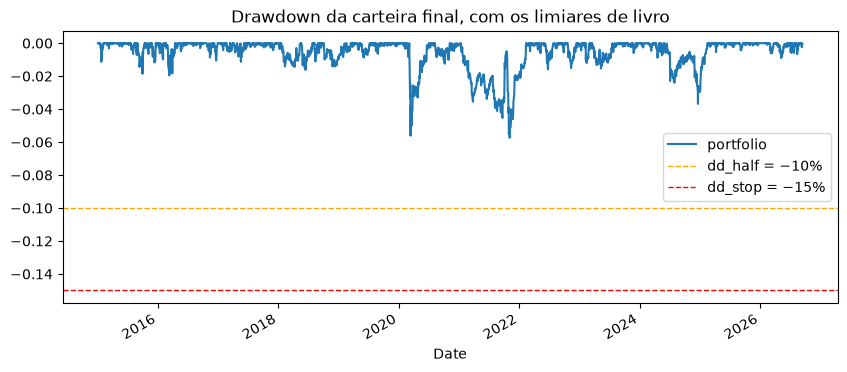

In [2]:
dd = metrics.drawdown(p)
print(f"drawdown máximo: {dd.min():.2%} em {dd.idxmin():%Y-%m-%d}")
print(f"percentis do drawdown: p1 {dd.quantile(0.01):.2%} | p5 {dd.quantile(0.05):.2%} | mediana {dd.median():.2%}")
print(f"dias em drawdown: {(dd < -1e-12).mean():.0%}")

ax = dd.plot(title="Drawdown da carteira final, com os limiares de livro")
ax.axhline(-0.10, color="orange", ls="--", lw=1, label="dd_half = −10%")
ax.axhline(-0.15, color="red", ls="--", lw=1, label="dd_stop = −15%")
ax.legend();

**O gráfico já responde a seção 2.** O pior drawdown da carteira em quase doze anos é de **−5,73%**, e as duas linhas tracejadas estão em −10% e −15%: a série nunca chega perto delas. Não é mérito da regra, é consequência da carteira — 84% do dinheiro está no carry, que tem vol de 1,0% ao ano.  O primeiro percentil do drawdown fica em torno de −4%, e é esse número que a seção 2 usa para recalibrar os limiares. Guarde também que a carteira passa **73% dos pregões em drawdown**: com vol baixa e retorno abaixo do CDI, ela demora para fazer topo novo.

dias por estado: {1.0: 2912}


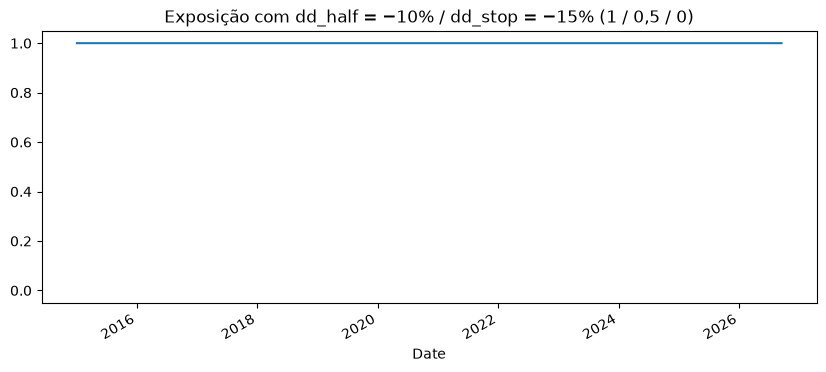

In [3]:
exposure = portfolio.drawdown_control(p)                  # limiares de livro: −10% / −15%
print("dias por estado:", exposure.value_counts().to_dict())
exposure.plot(title="Exposição com dd_half = −10% / dd_stop = −15% (1 / 0,5 / 0)", ylim=(-0.05, 1.05));

**2.912 pregões em exposição cheia, nenhum em HALF, nenhum em STOP.** A regra não é acionada
uma única vez nesta carteira.

Duas propriedades da regra que não são óbvias no laço e que mudam a leitura de qualquer
backtest dela:

- **o gatilho é o drawdown da carteira *sem* a regra** — uma curva-sombra. Não é o drawdown de
  quem segue a regra, logo o `max_dd` do resultado **não** fica limitado a `dd_stop`;
- **só se volta a FULL num novo topo histórico dessa sombra.** Depois de um STOP isso significa
  ficar de fora do repique inteiro, e na volta não se passa por HALF (nele só se entra vindo de
  FULL). Rearmar mais cedo — a −5% de drawdown, digamos — é outra regra, não esta.

A célula abaixo é o teste dessas duas coisas: uma série sintética construída para visitar os
três estados, e a conferência de que a função do pacote faz o mesmo que o laço escrito na mão.

In [4]:
# série sintética: sobe, cai o suficiente para HALF, cai mais para STOP, e sobe de novo
teste = pd.Series(np.concatenate([np.full(50, 0.002), np.full(60, -0.0021),
                                  np.full(20, -0.0025), np.full(200, 0.003)]),
                  index=pd.bdate_range("2020-01-01", periods=330))
exp_teste = portfolio.drawdown_control(teste, portfolio.DrawdownRule(-0.10, -0.15))
print("estados visitados na série sintética:", sorted(exp_teste.unique()))

# o mesmo laço, na mão, para conferir que a função do pacote não faz nada além disso
dd_ontem = dd.shift(1).fillna(0.0)
mao = np.empty(len(p)); state = 1.0
for t, d in enumerate(dd_ontem.to_numpy()):
    if d >= -1e-12:                     state = 1.0     # novo topo → FULL
    elif d < -0.15:                     state = 0.0     # STOP
    elif d < -0.10 and state == 1.0:    state = 0.5     # HALF, só vindo de FULL
    mao[t] = state
print("função do pacote == laço na mão:", bool((exposure.to_numpy() == mao).all()))

estados visitados na série sintética: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
função do pacote == laço na mão: True


## 2. Com e sem a regra

Duas comparações. Primeiro nos limiares de livro, onde já sabemos que a regra não dispara — o
teste serve para confirmar que aplicar a regra inerte não muda nada. Depois com os limiares
recalibrados para a escala de drawdown desta carteira, que é onde ela passa a decidir.

,sem regra,com regra
ret_anual,0.077,0.077
vol_anual,0.034,0.034
sharpe,-0.597,-0.597
max_dd,-0.057,-0.057


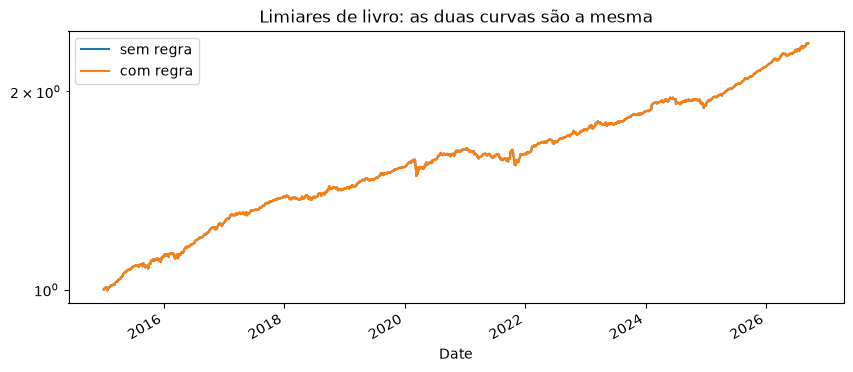

In [5]:
p_gerido = portfolio.apply_exposure(p, exposure, cdi)
pd.DataFrame({"sem regra": (1 + p).cumprod(), "com regra": (1 + p_gerido).cumprod()}).plot(
    logy=True, title="Limiares de livro: as duas curvas são a mesma")
pd.DataFrame({"sem regra": metrics.summary(p, cdi), "com regra": metrics.summary(p_gerido, cdi)}).round(3)

**Idênticas nas quatro métricas**, como tem que ser: com exposição 1,0 em todos os dias,
`apply_exposure` devolve a própria série. Vale como conferência de que o encanamento está
certo, e não como resultado.

dias em cheio/meio/zero: 2570/167/175  |  trocas de estado: 8


,sem regra,com regra
ret_anual,0.077,0.073
vol_anual,0.034,0.029
sharpe,-0.597,-0.863
max_dd,-0.057,-0.045


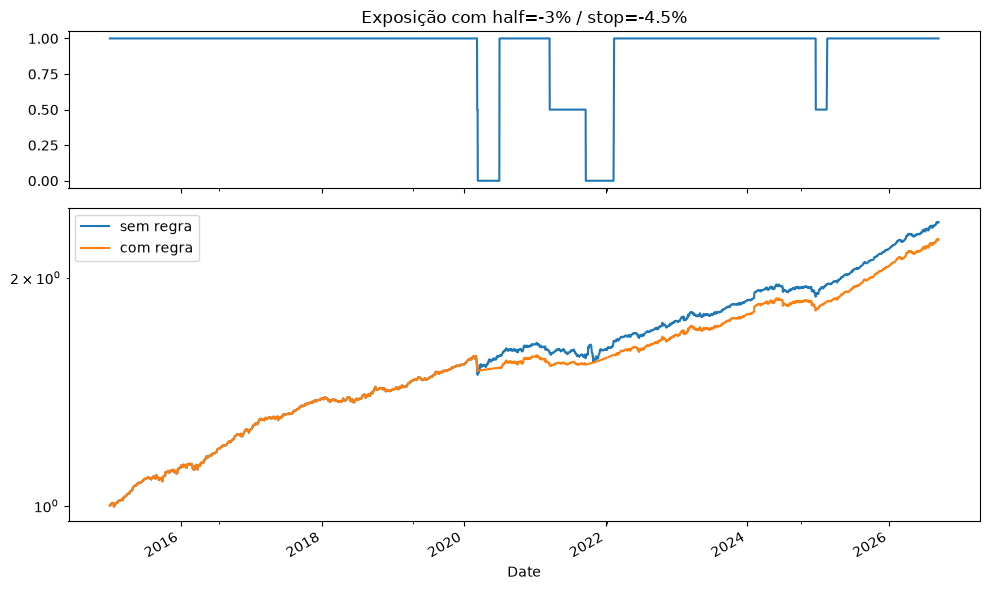

In [6]:
# limiares na escala desta carteira (o p1 do drawdown é ≈ −4%). CALIBRAGEM À POSTERIORI:
# os números foram escolhidos depois de ver o drawdown — leia como ilustração, não como resultado.
regra = portfolio.DrawdownRule(dd_half=-0.03, dd_stop=-0.045)
exp_cal = portfolio.drawdown_control(p, regra)
p_cal = portfolio.apply_exposure(p, exp_cal, cdi)

dias = exp_cal.value_counts().reindex([1.0, 0.5, 0.0]).fillna(0).astype(int)
trocas = int((exp_cal.diff() != 0).sum() - 1)
print(f"dias em cheio/meio/zero: {dias.iloc[0]}/{dias.iloc[1]}/{dias.iloc[2]}  |  trocas de estado: {trocas}")

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6), height_ratios=[1, 2])
exp_cal.plot(ax=ax1, title=f"Exposição com half={regra.dd_half:.0%} / stop={regra.dd_stop:.1%}", ylim=(-0.05, 1.05))
pd.DataFrame({"sem regra": (1 + p).cumprod(), "com regra": (1 + p_cal).cumprod()}).plot(ax=ax2, logy=True)
fig.tight_layout()
pd.DataFrame({"sem regra": metrics.summary(p, cdi), "com regra": metrics.summary(p_cal, cdi)}).round(3)

**A regra faz o que promete e cobra por isso.** Com −3%/−4,5% ela sai de casa: 342 dos 2.912 pregões ficam fora da exposição cheia (167 em meio, 175 em zero). O drawdown máximo cai de −5,7% para **−4,5%** e a vol de 3,4% para 2,9% — mas o retorno cai de 7,7% para 7,3% ao ano e o Sharpe piora de **−0,60 para −0,86**. A parada trava o prejuízo e perde o repique, que é exatamente a propriedade descrita na seção 1: só se volta a FULL num topo novo da sombra.  Três ressalvas antes de alguém levar esses limiares para a mesa:  1. **os números foram escolhidos depois de ver o drawdown.** Qualquer limiar calibrado assim    parece razoável no histórico em que foi calibrado; 2. **nenhuma das 8 trocas de estado paga corretagem.** Cada troca é um rebalanceamento de    verdade, de metade ou de toda a carteira, e o modelo de custo da Fase 5 não vê isso; 3. **numa carteira que rende menos que o CDI, cortar exposição *melhora* o retorno esperado.**    O fato de o Sharpe piorar mesmo assim é o que informa: a regra desliga nos momentos errados.

## 3. Contribuição de risco — de onde vem o risco que sobrou

Peso em dinheiro não é peso em risco. A conta que separa as duas coisas é a contribuição de
risco, que decompõe a variância da carteira sem sobra:

$$RC_i = w_i \cdot (\Sigma w)_i, \qquad \sum_i RC_i = \sigma_p^2$$

A alavancagem de 2× multiplica todas as contribuições pelo mesmo fator, então as **frações**
abaixo valem para a carteira final tanto quanto para a versão sem alavancagem.

          peso em dinheiro  fração do risco
momentum             0.033            0.257
reversao             0.025            0.273
pares                0.098            0.215
carry                0.844            0.254 

fração do risco em janela de 6 meses:
       momentum  reversao     pares     carry
count  2787.000  2787.000  2787.000  2787.000
mean      0.291     0.280     0.240     0.189
std       0.190     0.165     0.231     0.242
min      -0.064     0.018    -0.009    -0.006
25%       0.126     0.148     0.057     0.000
50%       0.289     0.278     0.188     0.059
75%       0.473     0.382     0.320     0.384
max       0.718     0.886     1.005     0.881


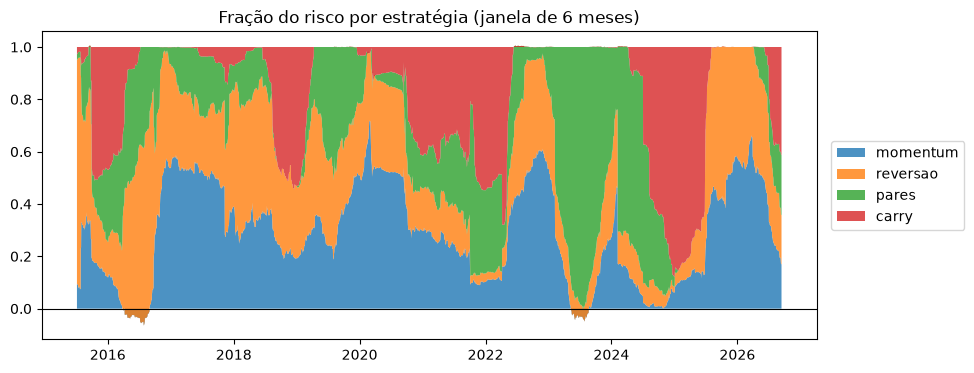

In [7]:
rc = portfolio.risk_contribution(R, w)
estatico = pd.DataFrame({"peso em dinheiro": w, "fração do risco": rc / rc.sum()}).round(3)

rc_rol = portfolio.rolling_risk_contribution(R, w, window=126)
print(estatico.to_string(), "\n")
print("fração do risco em janela de 6 meses:")
print(rc_rol.describe().round(3).to_string())

# fill_between empilhado na mão: as frações podem ser negativas, e .plot.area() exige sinal
# constante por coluna — com uma contribuição negativa ele empilha errado sem avisar
cum = rc_rol.cumsum(axis=1)
fig, ax = plt.subplots()
base = np.zeros(len(rc_rol))
for col in rc_rol.columns:
    ax.fill_between(rc_rol.index, base, cum[col], label=col, alpha=0.8)
    base = cum[col].to_numpy()
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Fração do risco por estratégia (janela de 6 meses)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5));

**O risco está dividido; o dinheiro não.** Na média das janelas de 6 meses cada estratégia
ocupa entre 19% e 29% da variância — que é o que a paridade de risco promete — e isso é obtido
com **84,4% do dinheiro no carry** e 3,3% no momentum. A carteira é uma posição em caixa com
uma pitada de ações, e é por isso que as frações de risco ficam parecidas.

Duas coisas que a janela móvel mostra e a conta estática esconde:

- **as frações passeiam muito.** O carry vai de ~0% a 88% da variância dependendo do semestre
  (desvio padrão de 0,24, o maior dos quatro): quando os juros ficam parados, ele quase não
  oscila e o risco migra todo para as ações;
- **contribuição pode ser negativa** (mínimos de −0,06 no momentum, −0,01 nos pares). Fração
  negativa é estratégia que *tira* risco do book naquele semestre. É por isso que o gráfico é
  um `fill_between` empilhado na mão e não um `.plot.area()`, que exige sinal constante.

Os pesos foram calculados com uma covariância de amostra única, e este gráfico é a prova de
que ela não descreve nenhum dos semestres em particular.

## 4. Episódios e cenários

Duas perguntas diferentes, e é útil não misturar:

- **episódios** — o que de fato aconteceu com esta carteira nos piores momentos da amostra;
- **cenários** — o que aconteceria com a carteira de hoje diante de um choque que a amostra não
  contém, estimado por sensibilidade (beta a mercado e a juros).

O segundo é mais frágil que o primeiro: beta medido na amostra vale para choque de tamanho
parecido com os da amostra, e supõe que a relação é linear e estável. Não é.

In [8]:
def episodios_drawdown(ret, n=5):
    """Os n piores episódios de drawdown: do topo anterior até a volta ao topo."""
    dd = metrics.drawdown(ret)
    em_dd = dd < -1e-12
    grupo = (em_dd != em_dd.shift()).cumsum()
    linhas = []
    for _, trecho in dd[em_dd].groupby(grupo[em_dd]):
        fundo = trecho.idxmin()
        linhas.append({"início": trecho.index[0].date(), "fundo": fundo.date(),
                       "fim": trecho.index[-1].date(), "profundidade": round(trecho.min(), 4),
                       "pregões": len(trecho), "até_o_fundo": trecho.index.get_loc(fundo) + 1,
                       "recuperou": trecho.index[-1] < dd.index[-1]})
    return pd.DataFrame(linhas).sort_values("profundidade").head(n).reset_index(drop=True)


episodios_drawdown(p)

,início,fundo,fim,profundidade,pregões,até_o_fundo,recuperou
0,2021-01-12,2021-11-03,2022-02-10,-0.0573,270,202,True
1,2020-03-05,2020-03-12,2020-07-01,-0.0561,81,6,True
2,2024-06-03,2024-12-19,2025-02-13,-0.0368,178,142,True
3,2016-02-19,2016-03-10,2016-04-12,-0.0196,37,15,True
4,2015-08-31,2015-09-29,2015-10-09,-0.0186,29,21,True


**Os dois piores episódios têm a mesma profundidade e nada mais em comum.**

- **2021 (−5,73%)**: 202 pregões de queda até o fundo e 270 até recuperar. É sangramento lento,
  e a causa está na seção seguinte — foi o ano em que a curva pré subiu junto com a Selic, e a
  carteira é essencialmente uma posição no pré.
- **covid, março de 2020 (−5,61%)**: o mesmo tamanho de perda em **6 pregões**, recuperado em 81.

A distinção importa para a regra da seção 2: um gatilho de drawdown reage tarde no episódio
rápido (o estrago já aconteceu quando o limiar é cruzado) e reage **muitas vezes** no episódio
lento, cortando exposição no meio de um mercado que ainda vai oscilar em torno do limiar. Os
dois piores casos desta carteira são, por acaso, um de cada tipo.

Nenhum dos cinco episódios chega a −6%, e todos recuperaram.

In [9]:
JANELAS = {"recessão 2015-16":     ("2015-01-02", "2016-12-31"),
           "covid (fev-abr/2020)": ("2020-02-01", "2020-04-30"),
           "aperto da Selic 2021": ("2021-01-01", "2021-12-31"),
           "juros altos 2022-23":  ("2022-01-01", "2023-12-31"),
           "2024-26":              ("2024-01-01", "2026-09-14")}

def total(s):
    return float((1 + s.dropna()).prod() - 1)      # retorno acumulado, não anualizado

linhas = {}
for nome, (a, b) in JANELAS.items():
    jan = slice(a, b)
    linhas[nome] = {"carteira": total(p[jan]), "CDI": total(cdi[jan]), "MKT (NEFIN)": total(F["MKT"][jan]),
                    "dd da carteira": metrics.max_drawdown(p[jan]), "pregões": len(p[jan])}
janelas = pd.DataFrame(linhas).T
print("MKT cobre a amostra até", F["MKT"].last_valid_index().date(), "— a última janela está incompleta nessa coluna")
janelas.round(3)

MKT cobre a amostra até 2026-07-03 — a última janela está incompleta nessa coluna


,carteira,CDI,MKT (NEFIN),dd da carteira,pregões
recessão 2015-16,0.262,0.287,-0.070,-0.020,495.0
covid (fev-abr/2020),-0.014,0.009,-0.290,-0.056,60.0
aperto da Selic 2021,-0.016,0.043,-0.143,-0.057,247.0
juros altos 2022-23,0.161,0.269,-0.008,-0.016,498.0
2024-26,0.270,0.389,-0.114,-0.037,676.0


**A carteira perde do CDI em todas as cinco janelas**, o que é apenas o Sharpe de −0,60 visto
de perto. O que muda de janela para janela é *como* ela perde:

- **na recessão de 2015-16 e em 2022-23 ela ganha dinheiro** (+26% e +16%), só que menos que o
  CDI (+29% e +27%) — em período de juro alto, uma carteira que é quase caixa acompanha o caixa
  de longe;
- **na covid ela cai 1,4% enquanto o mercado cai 29%.** É o melhor argumento a favor dela em
  todo o projeto: beta perto de zero é caro em bolsa que sobe e barato em bolsa que cai;
- **em 2021 ela é a única janela em que o drawdown chega ao máximo da amostra** com o mercado
  caindo só 14%. A perda dela naquele ano não é de bolsa, é de juros.

O MKT do NEFIN termina em 03/07/2026, então a última linha compara 676 pregões de carteira com
menos dias de mercado. A diferença não muda a leitura, mas o número não é comparável ao dos
outros.

In [10]:
import statsmodels.api as sm

reg = pd.concat([R.sub(cdi, axis=0), (p - cdi).rename("carteira"), F["MKT"]], axis=1).dropna()
print(f"regressão em {len(reg)} de {len(R)} dias, até {reg.index.max():%Y-%m-%d}")

X = sm.add_constant(reg["MKT"])
betas = {c: sm.OLS(reg[c], X).fit().params["MKT"] for c in R.columns}
beta_pf = sm.OLS(reg["carteira"], X).fit().params["MKT"]
print("betas por estratégia:", {c: round(b, 3) for c, b in betas.items()})
print(f"beta da carteira: {beta_pf:.3f} (direto em p)  |  {sum(w[c] * betas[c] for c in R.columns):.3f} "
      f"(Σ w·β, sem a alavancagem — é este o erro de subestimar por ~2×)")

for nome, choque in {"bolsa −15%": -0.15, "bolsa −30%": -0.30}.items():
    print(f"{nome}: carteira ≈ {beta_pf * choque:+.2%}")

regressão em 2853 de 2912 dias, até 2026-07-03
betas por estratégia: {'momentum': np.float64(0.935), 'reversao': np.float64(0.194), 'pares': np.float64(-0.076), 'carry': np.float64(0.002)}
beta da carteira: 0.055 (direto em p)  |  0.030 (Σ w·β, sem a alavancagem — é este o erro de subestimar por ~2×)
bolsa −15%: carteira ≈ -0.82%
bolsa −30%: carteira ≈ -1.64%


In [11]:
y = pd.read_parquet(DATA / "processed" / "curva_pre_1y.parquet")["y_1y"].reindex(p.index).ffill()
k = portfolio.vol_target_scale(portfolio.combine(R, w), target=0.10, window=21, max_leverage=2.0)
w_ef = k.iloc[-1] * w                                      # exposição efetiva de hoje, com alavancagem

jr = pd.concat([R["carry"].rename("carry"), y.diff().rename("dy")], axis=1).dropna()
fit_y = sm.OLS(jr["carry"], sm.add_constant(jr["dy"])).fit()
b_y = fit_y.params["dy"]
print(f"juros +300 bps num dia: carry {b_y * 0.03:+.2%}, carteira {w_ef['carry'] * b_y * 0.03:+.2%}"
      f"   (β = {b_y:.2f} por 100% de Δy, R² = {fit_y.rsquared:.2f}, y hoje = {y.iloc[-1]:.2%})")

vols = R.apply(metrics.annualized_vol)
print(f"correlações → 1: vol ≈ {float((w_ef * vols).sum()):.1%} vs atual {metrics.annualized_vol(p):.1%}")
print(f"  (sem alavancagem: teto {float((w * vols).sum()):.1%} vs {metrics.annualized_vol(portfolio.combine(R, w)):.1%}"
      f" — é aqui que a diversificação aparece)")

juros +300 bps num dia: carry -0.93%, carteira -1.57%   (β = -0.31 por 100% de Δy, R² = 0.33, y hoje = 13.68%)
correlações → 1: vol ≈ 6.9% vs atual 3.4%
  (sem alavancagem: teto 3.5% vs 1.8% — é aqui que a diversificação aparece)


**Os três cenários, e qual deles é o que importa.**

- **Bolsa.** O beta da carteira a mercado é **0,055**: uma queda de 30% na bolsa custa ~1,6%.
  Medido **direto na série alavancada**; fazer Σ w·β com os pesos sem alavancagem dá 0,030 e
  subestima por quase 2×, porque a alavancagem multiplica a exposição e não aparece nos pesos.
- **Juros.** +300 bps na pré de 1 ano em um dia custa ~1,6% na carteira, quase todo pelo carry
  (β de −0,31 por 100% de Δy, R² = 0,33). É o mesmo tamanho do choque de bolsa −30% — e um
  movimento de 300 bps na pré de 1 ano é muito menos extraordinário que uma queda de 30% na
  bolsa. **É este o risco da carteira**, e é coerente com o episódio de 2021 da seção anterior.
- **Correlações → 1.** Se todas as estratégias andassem juntas, a vol iria de 3,4% para **6,9%**
  (sem alavancagem: de 1,8% para 3,5%). Esse fator de ~2× é o tamanho exato do ganho de
  diversificação — e a seção 2 da Fase 6 mostra que ele encolhe justamente nos dias de estresse,
  quando momentum e reversão passam de +0,15 para +0,60 de correlação.

O R² de 0,33 da regressão de juros é o número que limita tudo isso: dois terços da variação do
carry não são explicados pelo movimento da taxa de 1 ano.

## 5. Exposição efetiva — o que a carteira de fato carrega

Os pesos da paridade de risco somam 1, mas a carteira final é multiplicada por $k_t$ todo dia.
A exposição que interessa é o produto.

k: mediana 2.00 | mín 1.00 | máx 2.00 | no teto de 2,0 em 98.2% dos dias
vol sem alavancagem 1.78% → com alavancagem 3.38% (alvo: 10,00%)
exposição efetiva hoje: {'momentum': 0.065, 'reversao': 0.05, 'pares': 0.195, 'carry': 1.689} | soma 2.00


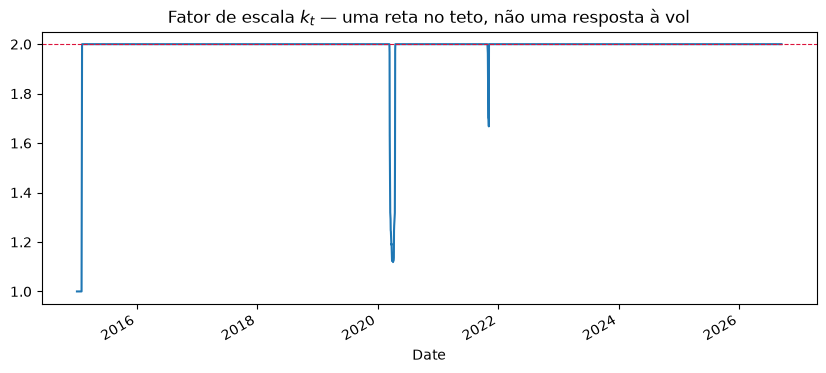

In [12]:
p_rp = portfolio.combine(R, w)

def vol_target_returns(ret, cdi, k, spread=0.0):    # a mesma da Fase 6: funding cobrado a CDI
    return k * ret - (k - 1).clip(lower=0) * (cdi + spread / 252) + (1 - k).clip(lower=0) * cdi

assert np.allclose(vol_target_returns(p_rp, cdi, k), p), "divergiu de portfolio_final.parquet"

print(f"k: mediana {k.median():.2f} | mín {k.min():.2f} | máx {k.max():.2f} | no teto de 2,0 em {(k >= 1.999).mean():.1%} dos dias")
print(f"vol sem alavancagem {metrics.annualized_vol(p_rp):.2%} → com alavancagem {metrics.annualized_vol(p):.2%} (alvo: 10,00%)")
print("exposição efetiva hoje:", w_ef.round(3).to_dict(), f"| soma {w_ef.sum():.2f}")
k.plot(title="Fator de escala $k_t$ — uma reta no teto, não uma resposta à vol").axhline(2.0, color="crimson", ls="--", lw=0.8);

**Não existe vol targeting nesta carteira.** O alvo de 10% exigiria 5,6× de alavancagem sobre
uma carteira de vol 1,8%, e o teto é 2: `k` fica grudado em **2,0 em 98,2% dos pregões** e nunca
cai abaixo de 1. O gráfico é uma reta na linha vermelha. O que manda aqui é o `max_leverage`,
não o alvo — o nome do mecanismo está errado.

E a exposição efetiva mostra o que isso significa em posição: **1,69 no carry**, 0,195 nos
pares, 0,065 no momentum e 0,05 na reversão, somando 2,0 de bruto. Ler "paridade de risco
alavancada" como carteira diversificada é um erro de leitura: em dinheiro, é uma posição de
1,7× na taxa pré de 1 ano. A seção 4 já tinha dito a mesma coisa pelo lado do choque de juros.

## 6. A tabela final

As linhas de risco da tabela do projeto, todas na mesma régua (Sharpe do excesso sobre o CDI,
base 252), com as duas referências que dão escala: a carteira sem alavancagem e o CDI.

In [13]:
final = {
    "rp sem alavancagem":              p_rp,
    "carteira final (rp 2×, CDI)":     p,
    "  + regra −10%/−15%":             p_gerido,
    "  + regra −3%/−4,5%":             p_cal,
    "CDI":                             cdi,
}
tabela = pd.DataFrame({nome: metrics.summary(s, cdi) for nome, s in final.items()}).T

cenarios = pd.Series({"bolsa −15%": beta_pf * -0.15, "bolsa −30%": beta_pf * -0.30,
                      "juros +300 bps": w_ef["carry"] * b_y * 0.03,
                      "correlações → 1 (vol)": float((w_ef * vols).sum())}, name="impacto")

# conferência: as três linhas de risco têm que bater com o que o pipeline gravou
csv = pd.read_csv(RAIZ / "reports" / "tabela_final.csv", index_col="serie")
for linha, nome in {"rp_alavancada_2x": "carteira final (rp 2×, CDI)",
                    "rp_alavancada_2x_corte_10_15": "  + regra −10%/−15%",
                    "rp_alavancada_2x_corte_3_4.5": "  + regra −3%/−4,5%"}.items():
    assert np.allclose(csv.loc[linha, ["ret_anual", "vol_anual", "sharpe", "max_dd"]].astype(float),
                       tabela.loc[nome].astype(float)), f"{linha} divergiu de reports/tabela_final.csv"
print("bate com reports/tabela_final.csv: True\n")
print(tabela.round(3).to_string(), "\n")
print("cenários sobre a carteira final:")
print(cenarios.round(4).to_string())

bate com reports/tabela_final.csv: True

                             ret_anual  vol_anual  sharpe  max_dd
rp sem alavancagem               0.089      0.018  -0.554  -0.028
carteira final (rp 2×, CDI)      0.077      0.034  -0.597  -0.057
  + regra −10%/−15%              0.077      0.034  -0.597  -0.057
  + regra −3%/−4,5%              0.073      0.029  -0.863  -0.045
CDI                              0.100      0.002     NaN   0.000 

cenários sobre a carteira final:
bolsa −15%              -0.0082
bolsa −30%              -0.0164
juros +300 bps          -0.0157
correlações → 1 (vol)    0.0693


**A tabela em três leituras.**

- **A alavancagem não pagou.** Dobrar a carteira a custo de CDI derrubou o retorno (8,9% → 7,7% ao ano) e dobrou a vol e o drawdown. Alavancar uma carteira que rende
  menos que o custo do dinheiro só multiplica o prejuízo, e o Sharpe registra isso indo de
  −0,55 para −0,60.
- **Nenhuma variante ganha do CDI.** O CDI fez 10,0% ao ano com drawdown zero; a melhor linha
  de risco aqui fez 7,7% com −5,7%. O controle de risco reduz perda, mas não existe controle de
  risco que conserte retorno esperado negativo.
- **A regra de corte só aparece na tabela quando os limiares são escolhidos depois do fato**, e
  aí piora o Sharpe. As duas linhas de regra são as que o `scripts/run_pipeline.py` grava, e a
  conferência acima garante que este notebook e o pipeline contam a mesma história.

Os cenários dizem o resto: o pior choque estimado (juros +300 bps, −1,6%) é **menor que o
drawdown que a carteira já realizou** em 2021 (−5,7%). Ou seja, o risco desta carteira não está
num dia ruim; está no ano ruim — na exposição contínua a uma taxa que sobe devagar.

## 7. Registro

**Os parâmetros desta fase, todos escolhidos por mim:**

| parâmetro | valor | onde entra | como foi escolhido |
|---|---|---|---|
| `dd_half` / `dd_stop` | **−10% / −15%** | `portfolio.DrawdownRule` | convenção de livro; **inerte** nesta carteira |
| `dd_half` / `dd_stop` (variante) | **−3% / −4,5%** | seção 2 | calibrado **depois** de ver o drawdown (p1 ≈ −4%) — ilustração |
| janela da contribuição rolante | **126 dias** | `rolling_risk_contribution` | 6 meses, por convenção; nunca testei outra |
| janelas dos episódios | **5 recortes** | seção 4 | escolhidos pelo calendário macro, não pelo resultado |
| choques dos cenários | **−15% / −30% de bolsa, +300 bps de juros** | seção 4 | ordens de grandeza usuais; o beta é linear e a amostra não tem choque desse tamanho |
| vol alvo / `max_leverage` | **10% ao ano / 2,0** | herdados da Fase 6 | o alvo é inalcançável; o teto é quem decide |

### O que ainda é otimista

1. **A regra de corte não paga o giro que ela mesma gera.** São 8 trocas de estado na variante
   calibrada, cada uma um rebalanceamento de metade ou de toda a carteira, todas de graça no
   modelo.
2. **Os betas dos cenários são lineares e medidos na amostra.** Beta de bolsa estimado num
   período sem choque de 30% em um dia não diz o que acontece num choque de 30% em um dia; e o
   R² de 0,33 na regressão de juros deixa dois terços da variação do carry sem explicação.
3. **O drawdown máximo de −5,7% é de uma carteira de 2015-2026 e de um universo de
   sobreviventes.** Herda inteiro o viés de sobrevivência da Fase 5 — inclusive no cálculo de
   risco, porque a série de retorno que alimenta todas as contas desta fase é a mesma.
4. **A contribuição de risco usa covariância de amostra única.** O gráfico da seção 3 mostra as
   frações passeando entre ~0 e 88% ao longo dos semestres; os pesos foram calculados para uma
   média que não descreve nenhum deles.
5. **Não há teste de liquidez nem de chamada de margem.** A alavancagem de 2× supõe crédito
   contínuo a CDI sem limite e sem chamada — as três hipóteses quebram exatamente no dia do
   choque que esta fase tenta medir.

**A conclusão da fase, em uma linha:** a carteira final tem risco pequeno e bem repartido entre
as estratégias, o risco que sobra é de juros e não de bolsa, e nenhuma ferramenta de controle de
risco desta fase transforma isso em retorno acima do CDI.